# What happens when you just leave a noisey qubit along


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
steel_blue, plum = "#4682B4", "#B44682"

# Rabi

In [22]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.00




# Integration parameters
tol = 10**-12
evaluation_points = 2001
evaluation_time = 8/0.005

# iteration parameters
detunings = np.linspace(-2*0.005, 2*0.005, 1001)

fids_rabi = []




for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq-detuning, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
    fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_rabi.append(fid_1)

rabi_freq = 0.005


In [23]:
time_index = np.argmin(np.abs(times - ( 4/ rabi_freq)))
final_fids_rabi = [fid[time_index] for fid in fids_rabi]
detunings_normalized = detunings / rabi_freq

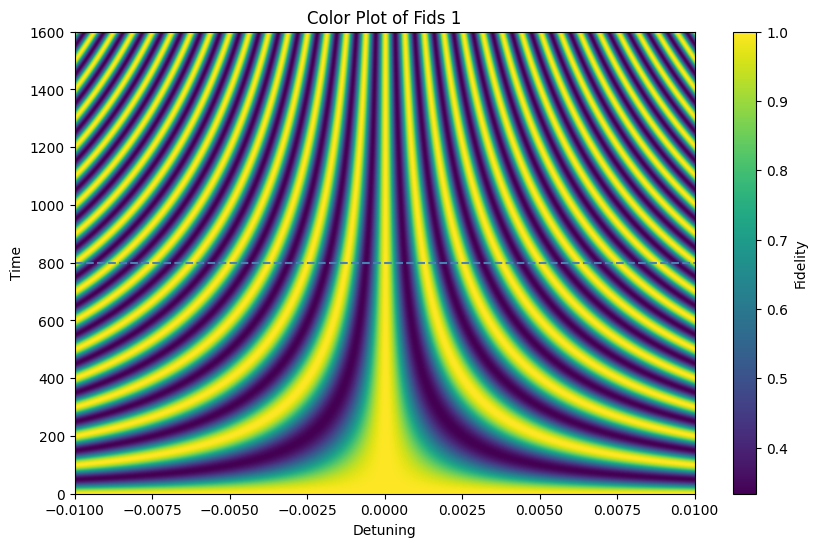

In [24]:
plt.figure(figsize=(10, 6))
plt.imshow(np.array(fids_rabi).T, aspect='auto', extent=[detunings[0], detunings[-1], 0, evaluation_time], origin='lower', cmap='viridis')
plt.axhline(y=4/rabi_freq, color=steel_blue, linestyle='--', label='4th Rabi Period')  # Add plum line
plt.colorbar(label='Fidelity')
plt.xlabel('Detuning')
plt.ylabel('Time')
plt.title('Color Plot of Fids 1')
plt.show()

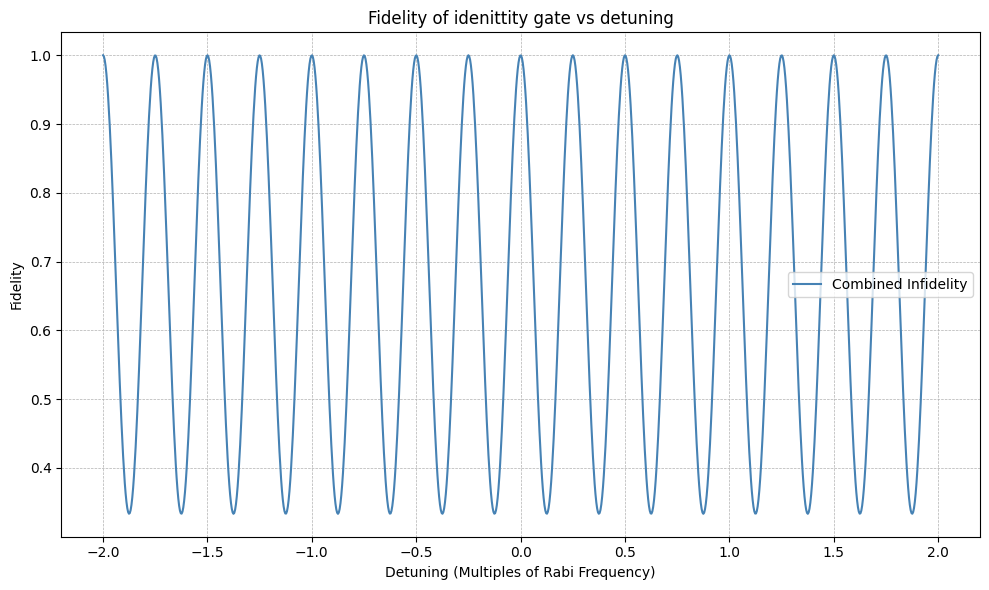

In [16]:


# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.plot(detunings_normalized, final_fids_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning (Multiples of Rabi Frequency)")
plt.ylabel("Fidelity")
plt.title("Fidelity of idenittity gate vs detuning")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


- I am going to choose to do it after 4 rabi oscillations for both - as that makes it fairer??

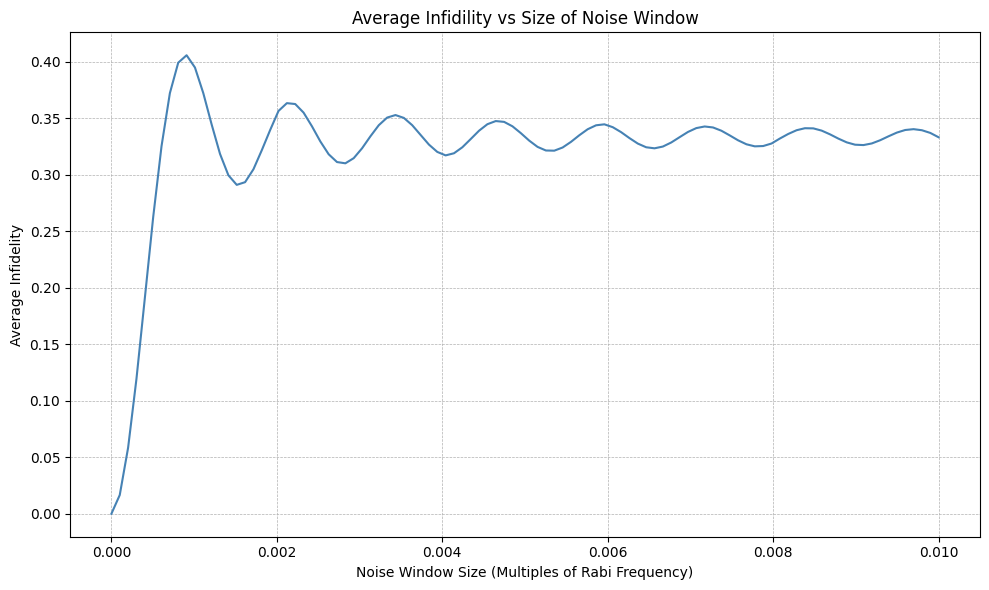

In [40]:
# Define the range of delta values
delta_values = np.linspace(0, max(detunings), 100)

# Calculate the average fidelity for each delta
average_infidelities_rabi = []
for delta in delta_values:
    indices = np.where((detunings >= -delta) & (detunings <= delta))
    avg_fid = np.mean([(1-final_fids_rabi[i]) for i in indices[0]])
    average_infidelities_rabi.append(avg_fid)

# Plot the average fidelity against delta
plt.figure(figsize=(10, 6))
plt.plot(delta_values, average_infidelities_rabi, color=steel_blue, label="Average Infidelity")
plt.xlabel("Noise Window Size (Multiples of Rabi Frequency)")
plt.ylabel("Average Infidelity")
plt.title("Average Infidility vs Size of Noise Window")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.legend()
plt.tight_layout()
plt.show()

# Combined - logged and greyed

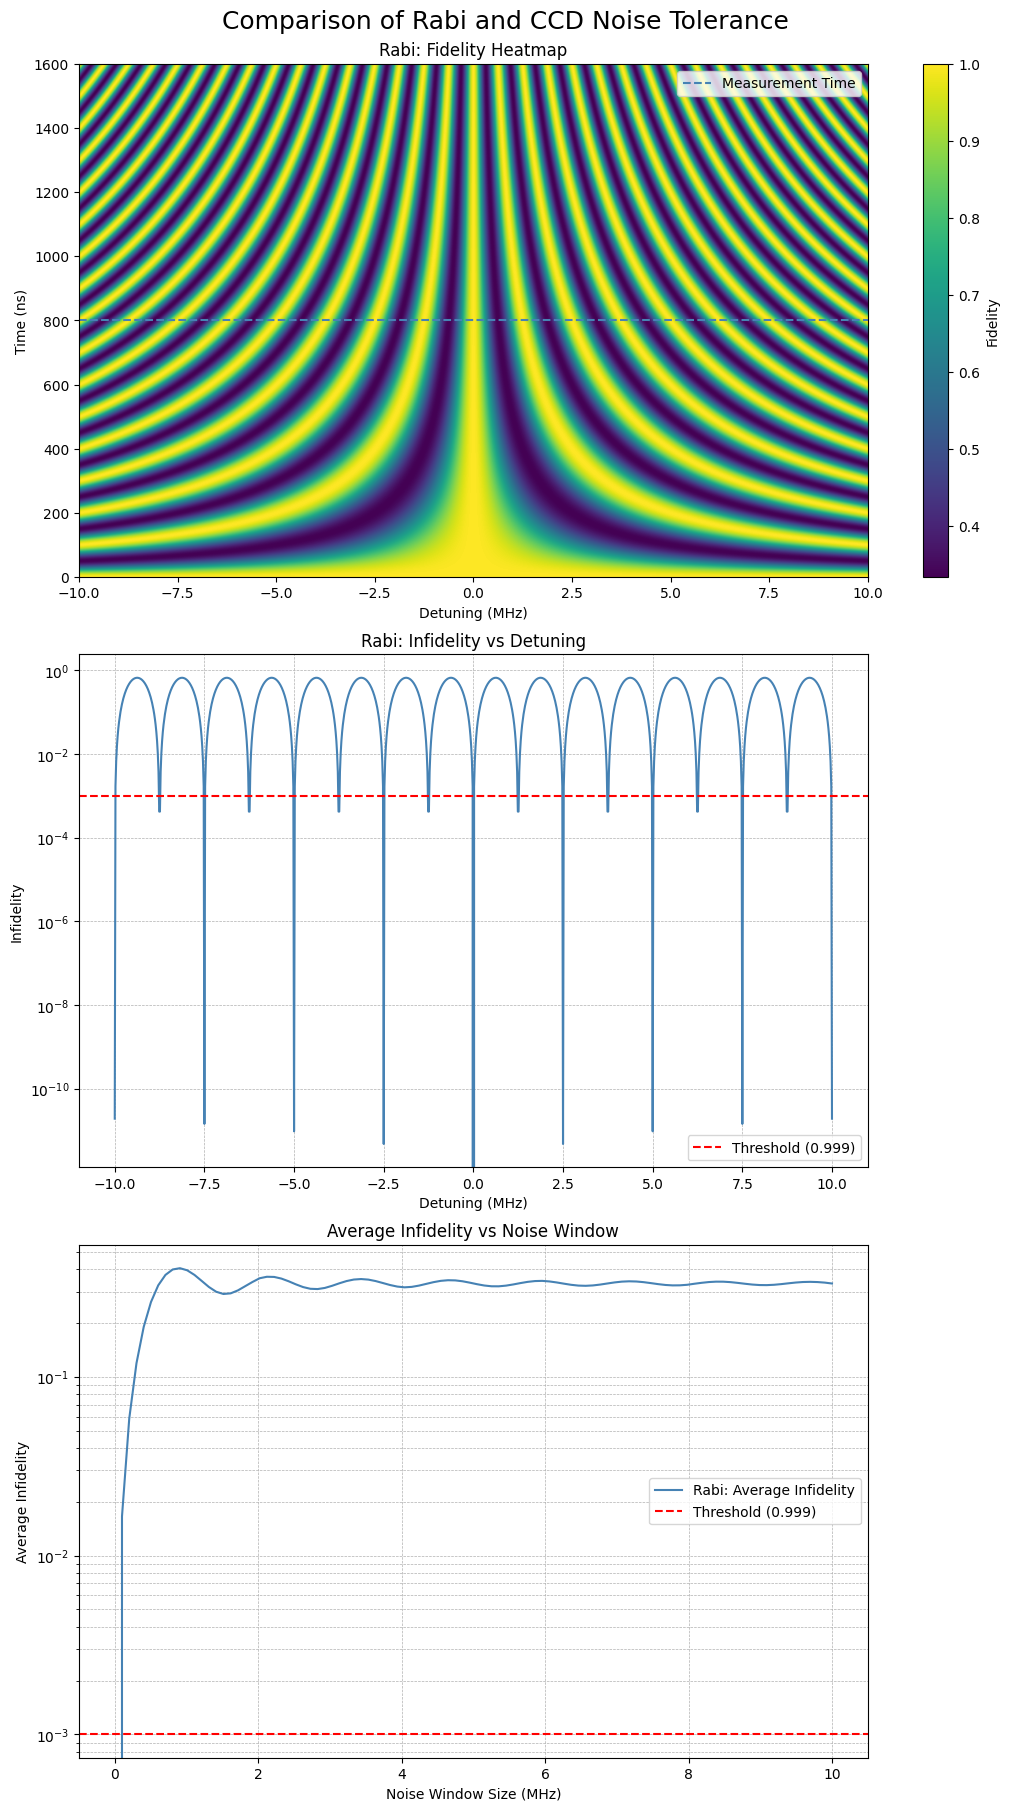

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18), constrained_layout=True)

# Top row: Heatmap
im1 = axes[0].imshow(np.array(fids_rabi).T, aspect='auto', extent=[detunings[0]*1000, detunings[-1]*1000, 0, evaluation_time ], origin='lower', cmap='viridis', vmin=1/3, vmax=1)
axes[0].axhline(y=800, color=steel_blue, linestyle='--', label='Measurement Time')
axes[0].set_title("Rabi: Fidelity Heatmap")
axes[0].set_xlabel("Detuning (MHz)")
axes[0].set_ylabel("Time (ns)")
axes[0].legend(loc='upper right')
fig.colorbar(im1, ax=axes[0], label="Fidelity")

# Middle row: Infidelity vs Detuning
axes[1].semilogy(detunings*1000, 1 - np.array(final_fids_rabi), color=steel_blue)
axes[1].axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")
axes[1].set_title("Rabi: Infidelity vs Detuning")
axes[1].set_xlabel("Detuning (MHz)")
axes[1].set_ylabel("Infidelity")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[1].legend(loc='lower right')

# Bottom row: Average Infidelity vs Noise Window
axes[2].semilogy(delta_values*1000, average_infidelities_rabi, color=steel_blue, label="Rabi: Average Infidelity")
axes[2].axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")
axes[2].set_title("Average Infidelity vs Noise Window")
axes[2].set_xlabel("Noise Window Size (MHz)")
axes[2].set_ylabel("Average Infidelity")
axes[2].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[2].legend()

plt.suptitle("Comparison of Rabi and CCD Noise Tolerance", fontsize=18)
plt.savefig('/Users/archie/documents/year4/project/Figures/phase_errors_noise_tolerance.png', dpi=600)
plt.show()

